### Ensure necessary tools are present and working

In [1]:
import sklearn
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from econml.dml import CausalForestDML
from econml.validate import DRTester
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import shap

print(sklearn.__version__)

/media/studies/ehr_study/analysis/mferguson/venvs/causal_forest_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1.6.1


### Imports from existing scripts

In [2]:
import sys
from pathlib import Path
import os
sys.path.append(str(Path(os.getcwd()).parent))
Path(os.getcwd())

from scripts.pipeline.predictions.create_train_test_split import create_train_test_split
from scripts.shared.utils import load_trd_set, load_feature_matrix

### Creation of data set with one-hot categorical encodings

In [3]:
train_ids, test_ids = create_train_test_split()
trd_set = load_trd_set()
X_train, X_test = load_feature_matrix(train_ids), load_feature_matrix(test_ids)
# Don't iterate over the raw sets of train and test ids for y; use X_train and X_test index references to preserve order
y_train, y_test = np.array([1 if id in trd_set else 0 for id in X_train.index]), np.array([1 if id in trd_set else 0 for id in X_test.index])

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# Drop all of the columns that are treatments whose effect we want to estimate
treatment_cols = ['polypharmacy_count', 'trials_BUPROPION', 'trials_MIRTAZAPINE', 'trials_SNRI', 'trials_SSRI', 'trials_VORTIOXETINE', 'augmentation_occured']
X_reduced_train = X_train.drop(columns=treatment_cols)
X_reduced_test = X_test.drop(columns=treatment_cols)
print(X_reduced_train.shape, X_reduced_test.shape)

# Concatenate training and testing into the entire population
X_full = pd.concat([X_train, X_test])
print(X_full.shape)

Found 9724 total patients.
Split into train set of size 7779 and test set of size 1945.
Train set TRD count: 827
Test set TRD count: 207
(7779, 59) (1945, 59) (7779,) (1945,)
(7779, 52) (1945, 52)
(9724, 59)


In [4]:
POLYPHARMACY_THRESHOLD=2
TRIALS_COLS=['trials_BUPROPION', 'trials_MIRTAZAPINE', 'trials_SNRI', 'trials_SSRI', 'trials_VORTIOXETINE']
SURVIVING_TREATMENTS=['polypharmacy', 'adequate_trial']
SURVIVING_TREATMENT_NAMES = {
    'polypharmacy': f'Medications active at index at least {POLYPHARMACY_THRESHOLD}',
    'adequate_trial': 'At least one medication arm having an adequate set of trials'
}

def get_treatment_indicator(patient_id: str, treatment: str) -> int:
    """Whether treatment was used on patient or not

    Args:
        patient_id (str): Respective patient
        treatment (str): Respective treatment

    Returns:
        int: Flag to indicate if treatment was applied to patient
    """
    patient_row = X_full.loc[patient_id]
    if treatment == 'polypharmacy':
        return int(patient_row['polypharmacy_count'] >= POLYPHARMACY_THRESHOLD)
    elif treatment == 'adequate_trial': # At least one arm of medication treatments had an adequate set of trials
        return int(patient_row[TRIALS_COLS].sum() >= 1)
    elif treatment == 'augmentation':
        return int(patient_row['augmentation_occured'])
    else:
        raise ValueError(f"Unrecognized treatment: {treatment}")

# For each treatment, determine if each train or test patient received it or not
T_train = {
    treatment: np.array([get_treatment_indicator(pid, treatment) for pid in X_reduced_train.index])
    for treatment in SURVIVING_TREATMENTS
}
T_test = {
    treatment: np.array([get_treatment_indicator(pid, treatment) for pid in X_reduced_test.index])
    for treatment in SURVIVING_TREATMENTS
}

for arr in T_train.values():
    print(arr.shape)

for arr in T_test.values():
    print(arr.shape)

(7779,)
(7779,)
(1945,)
(1945,)


In [5]:
cat_cols = ["Sex", "PreferredLanguage", "MaritalStatus", "Religion", "SmokingStatus", "Race_Ethnicity", "mdd_recurrence", "mdd_severity"]
X_reduced_full = pd.concat([X_reduced_train, X_reduced_test])
# Convert all categorical variables to one-hot encodings
X_encoded_full = pd.get_dummies(X_reduced_full, columns=cat_cols)
X_encoded_train, X_encoded_test = X_encoded_full.loc[X_reduced_train.index], X_encoded_full.loc[X_reduced_test.index]
print(X_encoded_train.shape, X_encoded_test.shape)

(7779, 81) (1945, 81)


### Implementation of causal random forest to estimate Conditional Average Treatment Effect (CATE)

In [6]:
causal_models, cate_test = {}, {}
seed = int(os.environ['SEED'])
save_folder = Path("figures")

for treatment in SURVIVING_TREATMENTS:
    model_y = RandomForestRegressor(random_state=seed, n_jobs=-1)
    model_t = RandomForestClassifier(random_state=seed, n_jobs=-1)
    n_estimators = 1000
    causal_forest = CausalForestDML(n_estimators=1000, model_y=model_y, model_t=model_t, random_state=seed, n_jobs=-1, discrete_treatment=True)
    # Fit with the train output, and whether this treatment was used on each patient in the training set
    causal_forest.fit(y_train, T_train[treatment], X=X_encoded_train, W=X_encoded_train)
    cate_test[treatment] = causal_forest.effect(X_encoded_test)
    causal_models[treatment] = causal_forest

os.makedirs(save_folder, exist_ok=True)
pd.DataFrame(cate_test, index=X_encoded_test.index).to_parquet(save_folder / "cate_test.parquet")

In [7]:
# For each treatment, create a histogram describing its importance over all patients
for treatment in SURVIVING_TREATMENTS:
    effect_vector = cate_test[treatment]
    fig, ax = plt.subplots()
    ax.hist(effect_vector, bins=100)
    ax.axvline(effect_vector.mean(), color='red', linestyle="--", label='Average effect')
    ax.axvline(0, color='green', linestyle='--', label='No effect')
    ax.set_xlabel("Estimated CATE on P(TRD)")
    ax.set_ylabel("Number of patients")
    ax.set_title(SURVIVING_TREATMENT_NAMES[treatment])
    ax.legend()
    fig.savefig(save_folder / f"{treatment}_CATE_histogram.png")
    plt.close(fig)

### Perform Heterogeneity tests

In [8]:
dr_testers = {}
cal_results = {}

for treatment in SURVIVING_TREATMENTS:
    tester = DRTester(
        model_regression=RandomForestRegressor(random_state=seed), # One regressor to estimate mu1/mu0, probabilities of being TRD given receiving treatment and not receiving treatment, over all patients
        model_propensity=RandomForestClassifier(random_state=seed), # Estimates e(x), probability of being treated
        cate=causal_models[treatment], # Already-fitted forest
        cv=5, # Cross validation sweep
    )
    tester.fit_nuisance(
        Xval=X_encoded_test.to_numpy(), # Patients with the treatment attribute removed and all others kept
        Dval=T_test[treatment], # Binary treatment flags
        yval=y_test, # TRD flags
        Xtrain=X_encoded_train.to_numpy(),
        Dtrain=T_train[treatment],
        ytrain=y_train
    )
    dr_testers[treatment] = tester # Store fitted tester
    
    # Obtain calibration - R^2 between causal forests's tau_hat over bins of patients, and the tester's estimates for treatment
    cal_results[treatment] = tester.evaluate_cal(
        Xval=X_encoded_test, # Leave as pandas array
        Xtrain=X_encoded_train,
        n_groups=10 # Number of bins
    )

#### Show calibration results

{'polypharmacy': <bound method CalibrationEvaluationResults.summary of <econml.validate.results.CalibrationEvaluationResults object at 0x7fafac110b10>>, 'adequate_trial': <bound method CalibrationEvaluationResults.summary of <econml.validate.results.CalibrationEvaluationResults object at 0x7faf944a8c10>>}


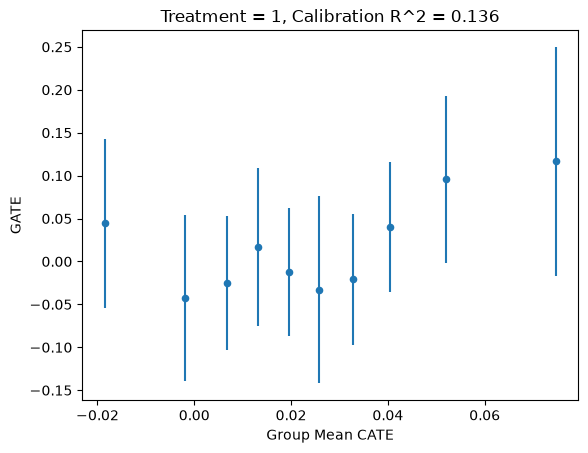

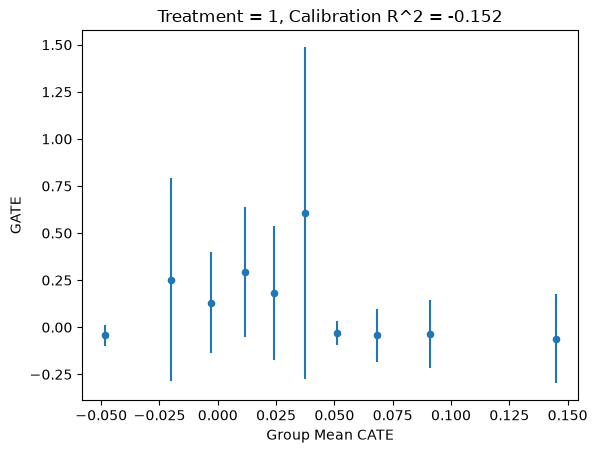

In [9]:
print({k: res.summary for k, res in cal_results.items()})
for treatment in SURVIVING_TREATMENTS:
    cal_results[treatment].plot_cal(
        tmt=1 # binary treatment
    ).figure.savefig(save_folder / f"{treatment}_calibration.png")

### For a given test patient, analyze their distribution of alpha values over the training patients...

In [10]:
treatment = 'polypharmacy' # This one was better behaved

model = causal_models[treatment]
inner_forest = model.model_cate.estimators_[0]
train_leaves = inner_forest.apply(X_encoded_train.to_numpy())
train_leaves.shape # n_training_patients x n_trees - over all training patients, which leaf do they belong to in each tree?

(7779, 1000)

(1, 1000)
(7779, 1000)
(1000,)


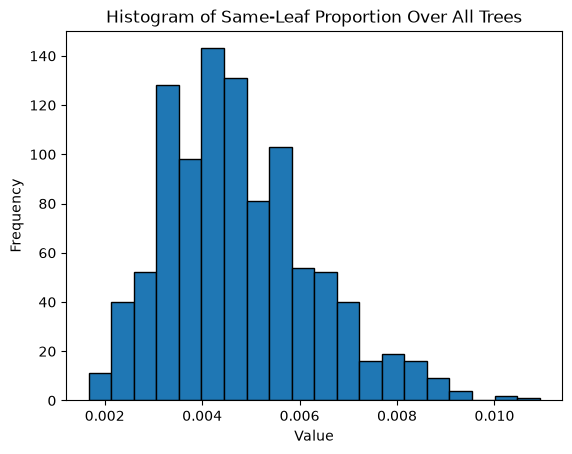

In [18]:
test_patient = X_encoded_test.iloc[[0]]
test_leaves = inner_forest.apply(test_patient.to_numpy()) # Which leaf did this patient end up in over all the trees in our causal forest?
print(test_leaves.shape) # 1 x n_trees

# For each tree, which patients landed in the same leaf as this test patient?
same_leaf = train_leaves == test_leaves # Broadcasting - shape n_training_patients x n_trees
print(same_leaf.shape)
# Take column average to see - over all the trees, each one's proportion of training patients that ended up having the same leaf as our test patient
avgs = np.mean(same_leaf, axis=0)
print(avgs.shape) # 1 x n_trees
plt.hist(avgs, bins=20, edgecolor='black')
plt.title("Histogram of Same-Leaf Proportion Over All Trees")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.savefig(save_folder / f"same_leaf_proportion_{treatment}.png")

(7779,)
1.0
0.005122227460467587


,alpha,trd,treated
patient_id,,,
0132879700D7100F8898D55C3FDE3A87,0.005122,0,1
A02BA4742A84128F049B0E8C8CD5C8DA,0.004974,0,1
C95412F1D6B32A5726232AE41C71D5F8,0.004943,0,1
D5B39D60CC6B139DFA76536CC8E67BDA,0.004808,1,1
28A938D0D46482A21B139B1D044CDF8A,0.004718,0,1
928879D30157E533E4E302B9176AB308,0.004695,0,1
EA9D806656C4C76FE3F231AF136B47B0,0.004624,0,1
84F12E6889BC6A3B64118F082B34A25E,0.004593,0,0
217AE8E50AD633C9A9A119AD34BE91D4,0.004399,0,1


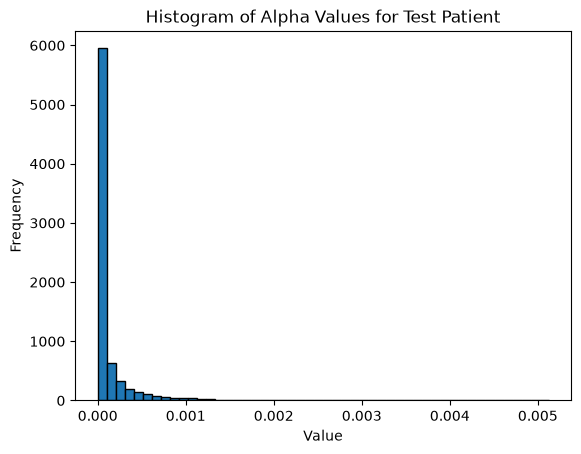

In [30]:
# That wasn't the alpha value distribution - wrong axis
# We want the weighted proportion of TREES in which each training patient was in the same leaf as our test patient
leaf_counts = np.sum(same_leaf, axis=0) # n_trees x 1; For each tree, this test patient ended up in a leaf - how big was that leaf?
same_leaf_scaled = same_leaf / leaf_counts # n_training_patients x n_trees; Now if a training patient is in the same leaf as the testing patient, their '1' flag is scaled down by the size of that leaf
alphas = np.mean(same_leaf_scaled, axis=1) # n_training_patients x 1; Weighted proportion of trees in which each training patient is in the same leaf this testing patient lands in
print(alphas.shape)
print(alphas.sum())
print(alphas.max())
plt.hist(alphas, bins=50, edgecolor='black')
plt.title("Histogram of Alpha Values for Test Patient")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.savefig(save_folder / f"alpha_distribution_{treatment}.png")

# Also save in a series the training patients and their corresponding alpha values, if they were TRD, and if they were treated
training_patient_alphas = pd.Series(alphas, index=X_encoded_train.index)
trd_vals = pd.Series(y_train, index=X_encoded_train.index)
treatment_vals = pd.Series(T_train[treatment], index=X_encoded_train.index)
training_tree_df = pd.DataFrame({
    'alpha': training_patient_alphas,
    'trd': trd_vals,
    'treated': treatment_vals
}).sort_values(by='alpha', ascending=False)

training_tree_df.head(n=20)

In [31]:
# Package into a function
def audit_alpha_neighbors(treatment: str, test_posn: int, top_n: int=20) -> pd.DataFrame:
    """Find the training patients' alpha weights with respect to this test patient and store in a data frame to return

    Args:
        treatment (str): e.g. 'polypharmacy'
        test_posn (int): test patient's position in X_encoded_test
        top_n (int, optional): top patients to display. Defaults to 20.

    Returns:
        pd.DataFrame: resulting data frame
    """
    model = causal_models[treatment]
    inner_forest = model.model_cate.estimators_[0]
    train_leaves = inner_forest.apply(X_encoded_train.to_numpy())
    
    test_patient = X_encoded_test.iloc[[test_posn]]
    test_patient_id = X_encoded_test.index[test_posn]
    test_leaves = inner_forest.apply(test_patient.to_numpy()) # Which leaf did this patient end up in over all the trees in our causal forest?

    # For each tree, which patients landed in the same leaf as this test patient?
    same_leaf = train_leaves == test_leaves # Broadcasting - shape n_training_patients x n_trees
    # Take column average to see - over all the trees, each one's proportion of training patients that ended up having the same leaf as our test patient
    avgs = np.mean(same_leaf, axis=0)
    plt.hist(avgs, bins=20, edgecolor='black')
    plt.title("Histogram of Same-Leaf Proportion Over All Trees")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.savefig(save_folder / f"{test_patient_id}_same_leaf_proportion_{treatment}.png")
    plt.close()
    
    leaf_counts = np.sum(same_leaf, axis=0) # n_trees x 1; For each tree, this test patient ended up in a leaf - how big was that leaf?
    same_leaf_scaled = same_leaf / leaf_counts # n_training_patients x n_trees; Now if a training patient is in the same leaf as the testing patient, their '1' flag is scaled down by the size of that leaf
    alphas = np.mean(same_leaf_scaled, axis=1) # n_training_patients x 1; Weighted proportion of trees in which each training patient is in the same leaf this testing patient lands in
    plt.hist(alphas, bins=50, edgecolor='black')
    plt.title("Histogram of Alpha Values for Test Patient")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.savefig(save_folder / f"{test_patient_id}_alpha_distribution_{treatment}.png")
    plt.close()

    # Also save in a series the training patients and their corresponding alpha values, if they were TRD, and if they were treated
    training_patient_alphas = pd.Series(alphas, index=X_encoded_train.index)
    trd_vals = pd.Series(y_train, index=X_encoded_train.index)
    treatment_vals = pd.Series(T_train[treatment], index=X_encoded_train.index)
    training_tree_df = pd.DataFrame({
        'alpha': training_patient_alphas,
        'trd': trd_vals,
        'treated': treatment_vals
    }).sort_values(by='alpha', ascending=False)

    print(training_tree_df.head(n=top_n))
    return training_tree_df

In [32]:
audit_alpha_neighbors('polypharmacy', 432)

                                     alpha  trd  treated
patient_id                                              
2BFAB8299C6F35EE4BC09984AFBF7639  0.006131    0        1
BAD935A2CBE6606DA41CD7A5C84F7E8C  0.005309    0        1
7CF94C0A5963C7D1E87D40C77054E6F4  0.005032    1        0
8424A4EE4E80411ED5899A7B93255C67  0.004533    1        0
CFE745926ED85FB1DB8B7DFF4DB75070  0.004204    0        0
39951934E8BC4BD2374B88CB1DB6703F  0.004026    1        1
D595A9648F3ACE20A99D77B741409656  0.003982    1        1
A43F105FD2729E84B8C43C883C018515  0.003855    0        1
2125497B07CC7CE2FD810D11C86C609D  0.003821    1        0
364236359DF9C22B9D65CF728DF989F6  0.003770    0        1
A328E990593641BE215664102D21DE36  0.003587    1        1
249100B49096B48B9740A0146845590B  0.003443    0        1
E6DD10DBE0E7665C3D450DF77E863B6C  0.003352    0        0
52F9DB3DBF78472171804D7A77DF0F7F  0.003309    0        0
79FEFFBD12DA5F4D0B5956F9B4A60209  0.003265    1        1
95855D3A3D1542F69BD7C888FCF21BB

,alpha,trd,treated
patient_id,,,
2BFAB8299C6F35EE4BC09984AFBF7639,0.006131,0,1
BAD935A2CBE6606DA41CD7A5C84F7E8C,0.005309,0,1
7CF94C0A5963C7D1E87D40C77054E6F4,0.005032,1,0
8424A4EE4E80411ED5899A7B93255C67,0.004533,1,0
CFE745926ED85FB1DB8B7DFF4DB75070,0.004204,0,0
...,...,...,...
A1806FC0B1E53C7224DDED81EB421525,0.000000,0,0
A17E57ABC9CA25C16DA212CC7EF45DC5,0.000000,0,0
A177598ACA0FC26741A29F56615DC9FF,0.000000,0,0


### BLP Regression Step

In [33]:
blps = {}
for treatment in SURVIVING_TREATMENTS:
    blps[treatment] = dr_testers[treatment].evaluate_blp(
        Xval=X_encoded_test,
    )
    print(f"{treatment}: {blps[treatment].summary()}")

polypharmacy:    treatment  blp_est  blp_se  blp_pval
0          1    1.184   0.619     0.056
adequate_trial:    treatment  blp_est  blp_se  blp_pval
0          1   -1.073   1.187     0.366
